# Local one-day ST Vecchia conditional diagnostics, lag643

로컬 컴퓨터에서 2023년 7월 하루를 `lag643` Vecchia로 직접 fit하고, 같은 fitted model에서 두 diagnostic을 같이 계산하는 notebook입니다.

- max-min ordered curve: `max-min block -> local eigen rank -> hours pooled`
- eigen-sorted curve: pooled local conditional eigenvalue order

중요: 이 notebook은 더 이상 `lag432`로 patch하지 않습니다. `vecchia_conditional_eigen_sort_common_engine_061926.py`의 기본 `lag643` builder를 그대로 씁니다. 따라서 기존 Amarel eigen-sorted 결과와 훨씬 더 공정하게 비교할 수 있습니다.


In [1]:
from pathlib import Path
import contextlib
import gc
import importlib
import json
import os
os.environ.setdefault('MPLCONFIGDIR', str(Path(os.environ.get('TMPDIR', '/tmp')) / 'matplotlib'))
import random
import sys
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

try:
    import torch
    import faiss  # noqa: F401  # GEMS_TCO.orderings imports faiss.
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'This notebook needs torch and faiss. On this Mac, use a Jupyter kernel backed by '
        'faiss_env or gems_gpu; the base python3 kernel does not have these packages.'
    ) from exc

REPO_ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
SRC_DIR = REPO_ROOT / 'src'
ANALYSIS_DIR = REPO_ROOT / 'Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis'

for path in [SRC_DIR, ANALYSIS_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print('repo:', REPO_ROOT)
print('analysis:', ANALYSIS_DIR)
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())


repo: /Users/joonwonlee/Documents/GEMS_TCO-1
analysis: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis
torch: 2.5.1
cuda available: False


In [2]:
# -----------------------------------------------------------------------------
# Local run knobs
# -----------------------------------------------------------------------------
YEAR = 2023
MONTH = 7

# Default is July 7 because that is the current comparison case.
# Change DAY_IDX to 0 for July 1, etc. Random mode samples day_idx 0..29.
RANDOM_DAY = False
RANDOM_SEED = 61926
DAY_IDX = 6
if RANDOM_DAY:
    rng = random.Random(RANDOM_SEED)
    DAY_IDX = rng.randrange(0, 30)

DAY_SLICE = f'{DAY_IDX},{DAY_IDX + 1}'
MODEL_VARIANTS = ['matern_s03', 'gc_a075_b1', 'fine_tuned_gc']

DOMAIN_MODES = 'full'
MAXMIN_ORDER_MODE = 'block_rank'

# Use CPU locally. On a CUDA workstation change this to 'cuda'.
DEVICE = 'cpu'

# Match the Amarel eigen-sort script unless you want a faster smoke test.
LBFGS_STEPS = 8
LBFGS_EVAL = 20
TARGET_CHUNK_SIZE = 32
DIAG_CHUNK_SIZE = 64
SPLINE_N_POINTS = 4000
SPLINE_R_MAX = 30.0

RUN_STEM_LOCAL = 'real_july2023_vecchia_conditional_lag643_one_day_local_061926'
OUT_DIR = REPO_ROOT / 'outputs/day/local_eigen_analysis' / RUN_STEM_LOCAL / f'day{DAY_IDX + 1:02d}'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('day_idx:', DAY_IDX, 'day:', f'{YEAR}-{MONTH:02d}-{DAY_IDX + 1:02d}')
print('models:', MODEL_VARIANTS)
print('lag: 6/4/3')
print('LBFGS:', LBFGS_STEPS, LBFGS_EVAL)
print('out:', OUT_DIR)


day_idx: 6 day: 2023-07-07
models: ['matern_s03', 'gc_a075_b1', 'fine_tuned_gc']
lag: 6/4/3
LBFGS: 8 20
out: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/real_july2023_vecchia_conditional_lag643_one_day_local_061926/day07


## Import lag643 diagnostic engine

This cell reloads the common engine and the real-data max-min driver. We only use the driver for real-data asset loading, model specs, fine-tuned GC table, and domain metadata. The fitted model itself comes from the common engine default `lag643` builder.


In [3]:
import vecchia_conditional_eigen_sort_common_engine_061926 as sim_eig
import vecchia_conditional_maxmin_order_real_july2023_matern_gc_baselines_finetuned_domains_061926 as maxmin_driver

sim_eig = importlib.reload(sim_eig)
maxmin_driver = importlib.reload(maxmin_driver)

# Keep local output naming separate, but leave lag643 build_model untouched.
sim_eig.RUN_STEM = RUN_STEM_LOCAL
maxmin_driver.RUN_STEM = RUN_STEM_LOCAL
maxmin_driver.sim_eig = sim_eig
maxmin_driver.YEAR_MODEL_DEFAULTS = {YEAR: list(MODEL_VARIANTS)}
sim_eig.MODEL_SPECS = maxmin_driver.MODEL_SPECS

print('Vecchia spec:', sim_eig.VECCHIA_SPEC_NAME)
print('lag pattern:', sim_eig.LAG_COUNTS)
print('builder:', sim_eig.build_model.__name__)
assert tuple(sim_eig.LAG_COUNTS) == (6, 4, 3), 'Expected lag643 common-engine builder.'


Vecchia spec: corridor_width_4x4_lag643_delta0p126
lag pattern: (6, 4, 3)
builder: build_model


## Fit once, compute both diagnostics

For each model, the code fits once, computes `beta` and fitted covariance parameters once, then calls both:

- `conditional_maxmin_order_curve(model, params, beta, args)`
- `conditional_eigen_curve(model, params, beta, args)`

This is the clean comparison: the only difference between curves is the ordering/aggregation diagnostic, not the fit.


In [4]:
argv = [
    'local_lag643_one_day_both_diagnostics',
    '--years', str(YEAR),
    '--month', str(MONTH),
    '--days', DAY_SLICE,
    '--domain-modes', DOMAIN_MODES,
    '--daily-plot-domains', 'full',
    '--model-variants', *MODEL_VARIANTS,
    '--device', DEVICE,
    '--cuda-fallback', 'cpu',
    '--real-reference-advec-lon-abs', '0.126',
    '--target-chunk-size', str(TARGET_CHUNK_SIZE),
    '--diag-chunk-size', str(DIAG_CHUNK_SIZE),
    '--lbfgs-steps', str(LBFGS_STEPS),
    '--lbfgs-eval', str(LBFGS_EVAL),
    '--lbfgs-history', '10',
    '--spline-n-points', str(SPLINE_N_POINTS),
    '--spline-r-max', str(SPLINE_R_MAX),
    '--maxmin-order-mode', MAXMIN_ORDER_MODE,
    '--save-daily-curves',
    '--suppress-fit-prints',
    '--out-dir', str(OUT_DIR),
]

parser = maxmin_driver.build_arg_parser()
args = parser.parse_args(argv[1:])
maxmin_driver.MAXMIN_ORDER_LABEL = maxmin_driver.maxmin_order_label(args.maxmin_order_mode)

device = sim_eig.resolve_device(args)
print(' '.join(argv))
print('device:', device)
print('out:', OUT_DIR)

assets = maxmin_driver.load_real_domain_assets(args)
if len(assets) != 1:
    print('loaded assets:', len(assets))
asset = assets[0]
print('asset:', asset.year, asset.day_label, getattr(asset, 'domain_label', ''), 'valid', asset.n_valid, '/', asset.n_total)

summary_rows = []
curves_maxmin = {}
curves_eigen = {}

curve_root = OUT_DIR / 'daily_curves' / f'year_{asset.year}' / str(getattr(asset, 'domain_group', 'domain')) / str(getattr(asset, 'domain_label', 'domain'))
curve_root.mkdir(parents=True, exist_ok=True)

for model_variant in MODEL_VARIANTS:
    print('\n' + '-' * 90)
    print('Fitting once and diagnosing:', model_variant)
    model = None
    try:
        maxmin_driver.prepare_model_spec_for_asset(model_variant, asset)
        t_fit0 = time.time()
        fit_row, model, beta = sim_eig.fit_one_model(asset, model_variant, device, args)
        fit_elapsed = time.time() - t_fit0

        params = torch.as_tensor(
            sim_eig.physical_to_log_phi(
                {
                    'sigmasq': fit_row['est_sigmasq'],
                    'range_lat': fit_row['est_range_lat'],
                    'range_lon': fit_row['est_range_lon'],
                    'range_time': fit_row['est_range_time'],
                    'advec_lat': fit_row['est_advec_lat'],
                    'advec_lon': fit_row['est_advec_lon'],
                    'nugget': 0.0,
                }
            ),
            device=device,
            dtype=sim_eig.DTYPE,
        )

        t0 = time.time()
        curve_maxmin, diag_maxmin = sim_eig.conditional_maxmin_order_curve(model, params, beta, args)
        maxmin_s = time.time() - t0

        t0 = time.time()
        curve_eigen, diag_eigen = sim_eig.conditional_eigen_curve(model, params, beta, args)
        eigen_s = time.time() - t0

        curves_maxmin[model_variant] = curve_maxmin
        curves_eigen[model_variant] = curve_eigen

        curve_maxmin.round(sim_eig.ROUND_DECIMALS).to_csv(
            curve_root / f'real_{asset.year}_day{asset.day_idx + 1:02d}_full_{model_variant}_conditional_maxmin_order_curve.csv',
            index=False,
            float_format=f'%.{sim_eig.ROUND_DECIMALS}f',
        )
        curve_eigen.round(sim_eig.ROUND_DECIMALS).to_csv(
            curve_root / f'real_{asset.year}_day{asset.day_idx + 1:02d}_full_{model_variant}_conditional_eigen_sorted_curve.csv',
            index=False,
            float_format=f'%.{sim_eig.ROUND_DECIMALS}f',
        )

        row = {
            **fit_row,
            **maxmin_driver.domain_fields(asset),
            'fit_elapsed_s': fit_elapsed,
            'maxmin_diag_s': maxmin_s,
            'eigen_diag_s': eigen_s,
            'maxmin_mean_y2': diag_maxmin.get('mean_y2', np.nan),
            'maxmin_D': diag_maxmin.get('max_abs_bridge_scaled', np.nan),
            'maxmin_n_scores': diag_maxmin.get('n_conditional_scores', np.nan),
            'eigen_mean_y2': diag_eigen.get('mean_y2', np.nan),
            'eigen_D': diag_eigen.get('max_abs_bridge_scaled', np.nan),
            'eigen_n_scores': diag_eigen.get('n_conditional_scores', np.nan),
        }
        summary_rows.append(maxmin_driver.clean_json_value(row))

        print(
            pd.Series(
                {
                    'model': fit_row['model_label'],
                    'loss/obs': f"{fit_row['vecchia_loss_per_obs']:.5f}",
                    'maxmin mean_y2': f"{row['maxmin_mean_y2']:.5f}",
                    'maxmin D': f"{row['maxmin_D']:.2f}",
                    'eigen mean_y2': f"{row['eigen_mean_y2']:.5f}",
                    'eigen D': f"{row['eigen_D']:.2f}",
                    'fit_s': f'{fit_elapsed:.1f}',
                    'diag_s max/eig': f'{maxmin_s:.1f}/{eigen_s:.1f}',
                }
            ).to_string()
        )
    except Exception as exc:
        summary_rows.append(
            {
                'status': 'error',
                'model_variant': model_variant,
                'error': f'{type(exc).__name__}: {exc}',
                'traceback': traceback.format_exc(limit=12),
            }
        )
        traceback.print_exc()
    finally:
        if model is not None:
            del model
        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

summary = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / f'{RUN_STEM_LOCAL}_both_diagnostics_summary.csv'
summary.to_csv(summary_path, index=False, float_format=f'%.{sim_eig.ROUND_DECIMALS}f')
print('\nsummary:', summary_path)
display(summary)


local_lag643_one_day_both_diagnostics --years 2023 --month 7 --days 6,7 --domain-modes full --daily-plot-domains full --model-variants matern_s03 gc_a075_b1 fine_tuned_gc --device cpu --cuda-fallback cpu --real-reference-advec-lon-abs 0.126 --target-chunk-size 32 --diag-chunk-size 64 --lbfgs-steps 8 --lbfgs-eval 20 --lbfgs-history 10 --spline-n-points 4000 --spline-r-max 30.0 --maxmin-order-mode block_rank --save-daily-curves --suppress-fit-prints --out-dir /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/real_july2023_vecchia_conditional_lag643_one_day_local_061926/day07
device: cpu
out: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/real_july2023_vecchia_conditional_lag643_one_day_local_061926/day07

Loading real July data for 2023-07
--- Global Monthly Mean for 2023-7: 249.7131 ---
n hourly slots=248 grid=(18126, 2) monthly_mean=249.713148 domains=1
asset: 2023 2023-07-07 full valid 133803 / 145008

------------------------------------

,status,error,year,month,day_idx,day,model_variant,model_family,model_label,smooth,...,n_grid_full,fit_elapsed_s,maxmin_diag_s,eigen_diag_s,maxmin_mean_y2,maxmin_D,maxmin_n_scores,eigen_mean_y2,eigen_D,eigen_n_scores
0,ok,,2023,7,6,2023-07-07,matern_s03,matern,Matern s=0.3 nugget0,0.3,...,18126,482.564578,4.009404,3.785042,1.000063,8.520154,133803,1.000063,9.297689,133803
1,ok,,2023,7,6,2023-07-07,gc_a075_b1,cauchy,Baseline GC a=0.75 b=1 nugget0,NaN,...,18126,210.161328,2.656301,2.536751,1.000065,8.396348,133803,1.000065,6.759540,133803
2,ok,,2023,7,6,2023-07-07,fine_tuned_gc,cauchy,Fine tuned GC day-specific nugget0,NaN,...,18126,250.217450,2.660817,2.512169,1.000066,8.407271,133803,1.000066,5.003360,133803


## Plot both orderings

The upper row shows the cumulative curve. The lower row shows `curve - y=x`, which makes small model differences easier to see.


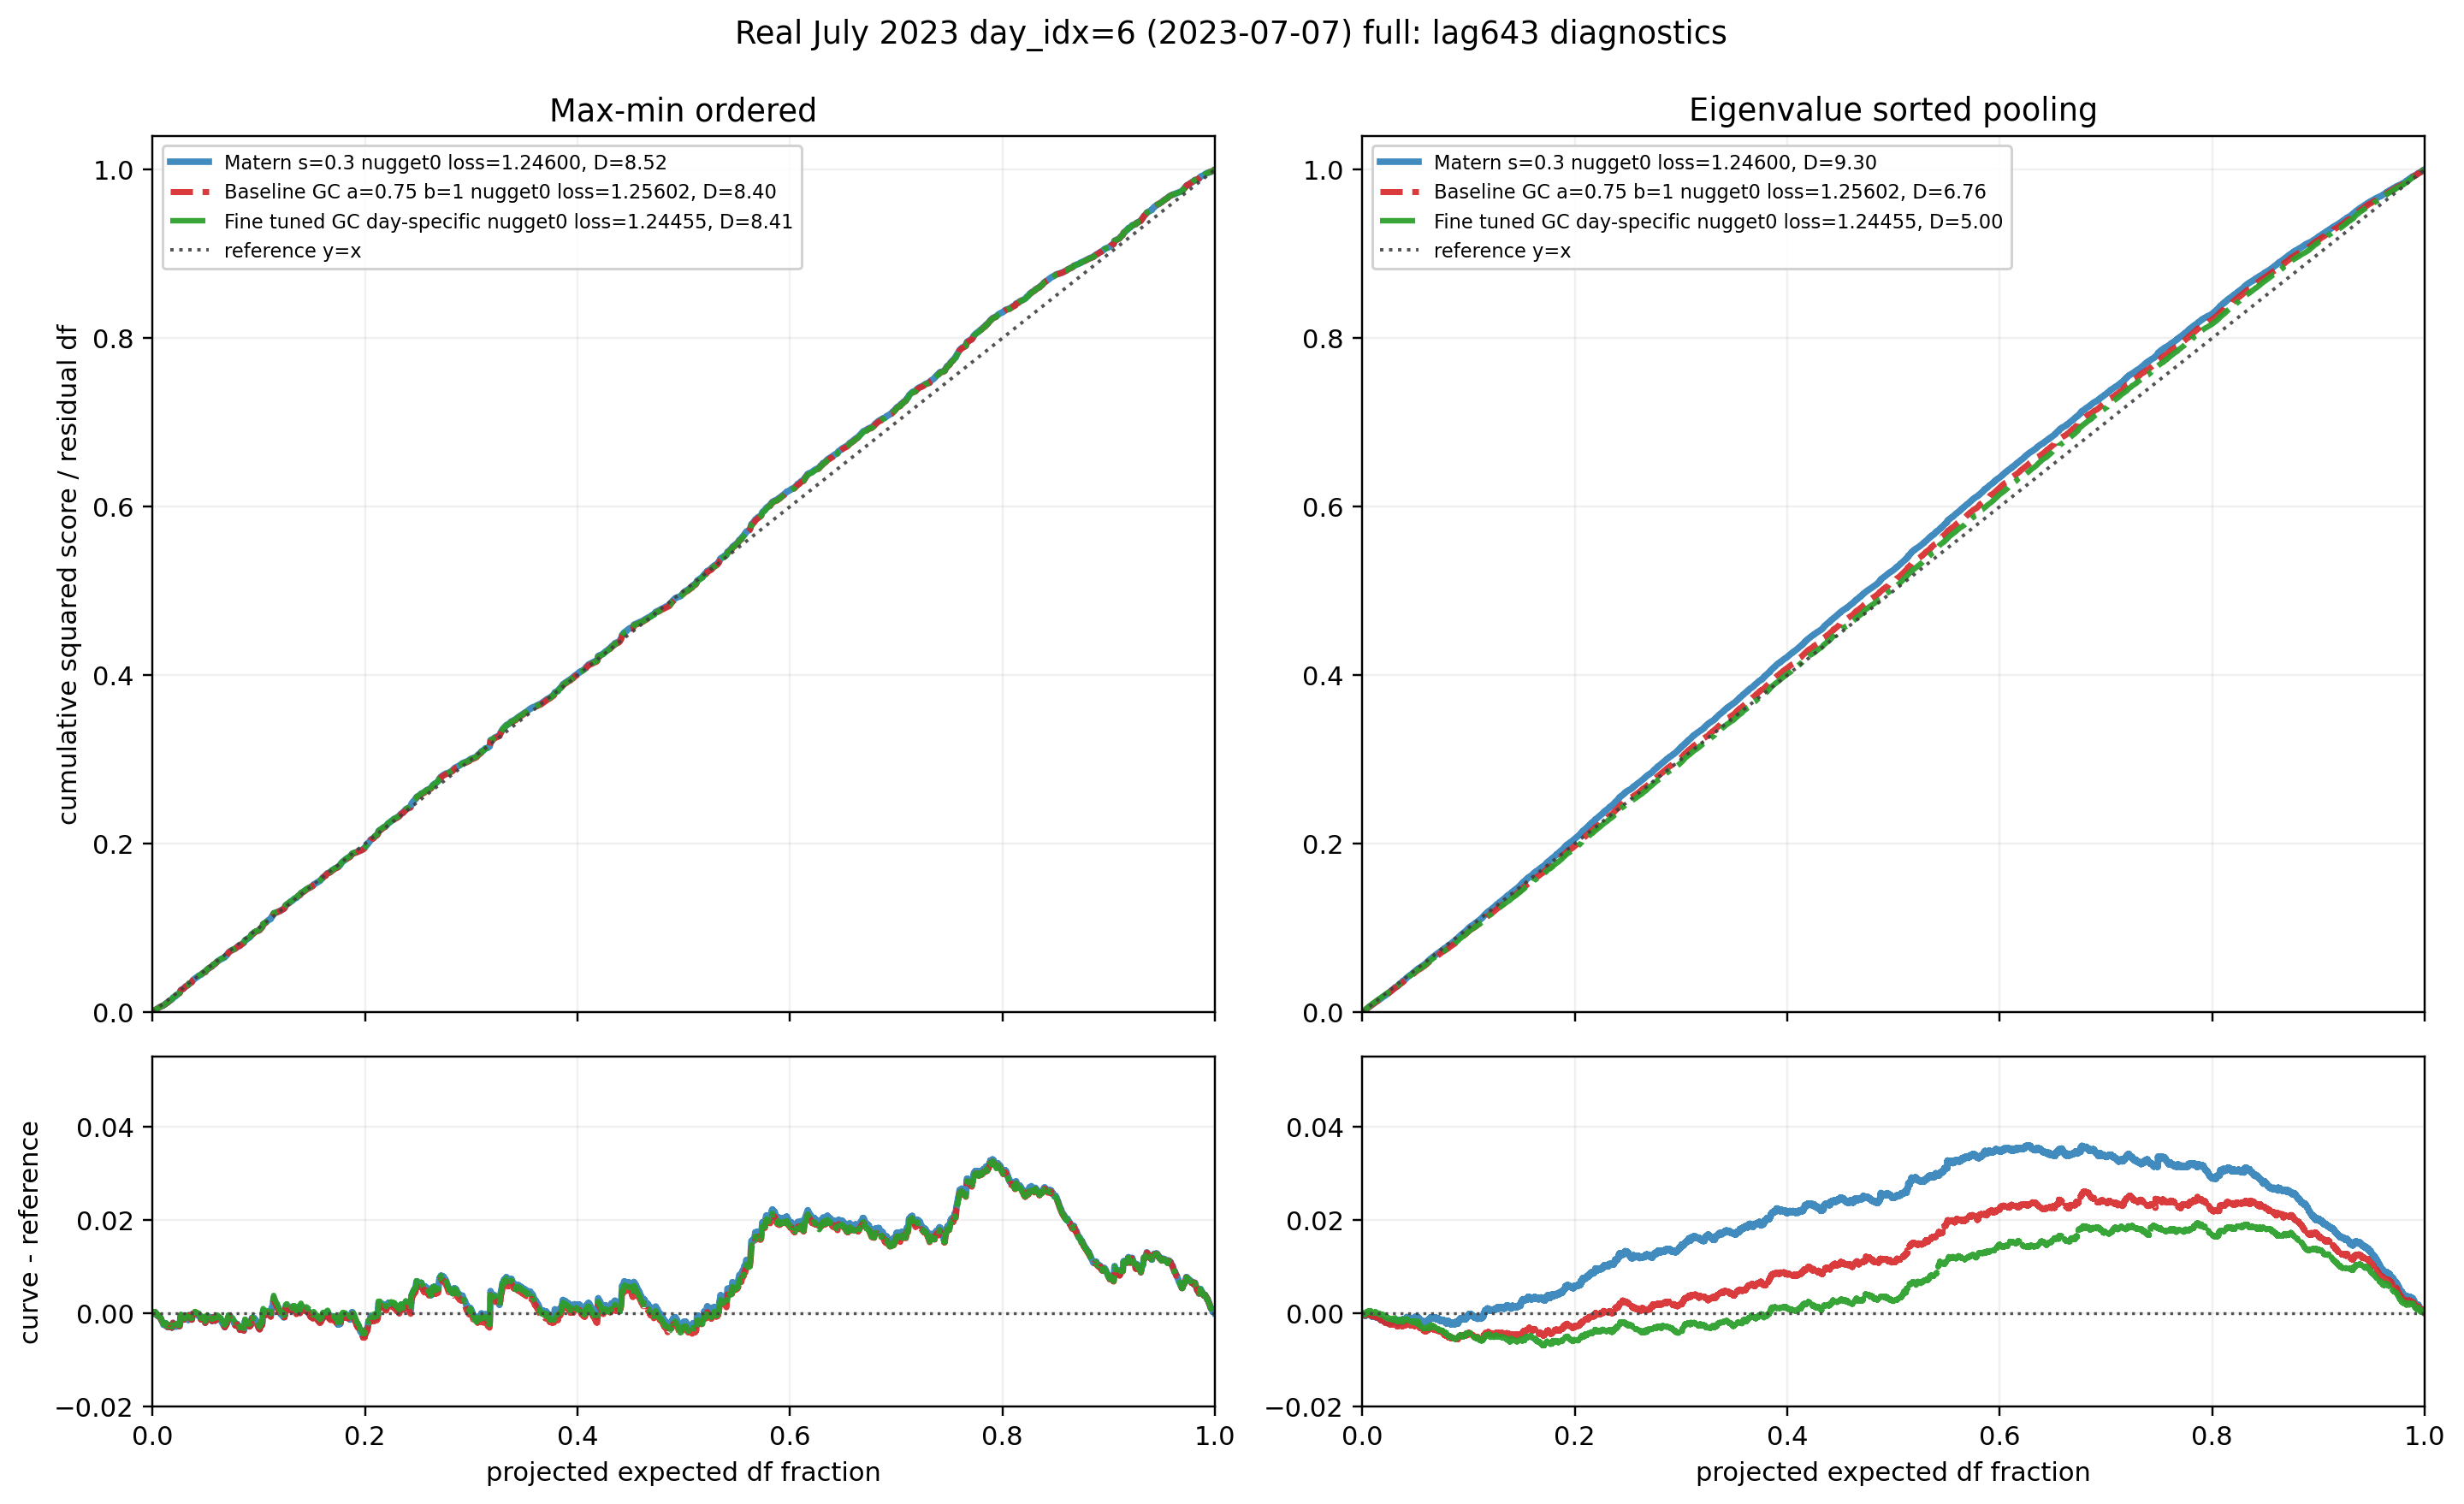

saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/real_july2023_vecchia_conditional_lag643_one_day_local_061926/day07/lag643_2023-07-07_full_maxmin_and_eigen_sorted_three_models.png


In [5]:
summary = pd.read_csv(OUT_DIR / f'{RUN_STEM_LOCAL}_both_diagnostics_summary.csv')
ok = summary[summary['status'].eq('ok')].copy()

year = int(ok['year'].iloc[0])
day_idx = int(ok['day_idx'].iloc[0])
day_label = str(ok['day'].iloc[0])
domain_label = str(ok['domain_label'].iloc[0])

styles = {
    'matern_s03': {'color': '#1f77b4', 'lw': 2.5, 'ls': '-',  'alpha': 0.85},
    'gc_a075_b1': {'color': '#d62728', 'lw': 2.3, 'ls': '--', 'alpha': 0.90},
    'fine_tuned_gc': {'color': '#2ca02c', 'lw': 2.1, 'ls': '-.', 'alpha': 0.95},
}

def load_curve(kind, model):
    suffix = 'conditional_maxmin_order_curve.csv' if kind == 'maxmin' else 'conditional_eigen_sorted_curve.csv'
    files = sorted(curve_root.glob(f'*_{model}_{suffix}'))
    if not files:
        raise FileNotFoundError((kind, model, curve_root))
    return pd.read_csv(files[0]).sort_values('frac_index')

def y_from_curve(curve, row):
    if 'scaled_cumsum' in curve.columns:
        return curve['scaled_cumsum'].to_numpy(float)
    return curve['cumsum_y2'].to_numpy(float) / float(row['residual_df'])

fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.0), sharex='col', gridspec_kw={'height_ratios': [3.0, 1.2]})
plot_specs = [
    ('maxmin', 'Max-min ordered', 'maxmin_D'),
    ('eigen', 'Eigenvalue sorted pooling', 'eigen_D'),
]

for col, (kind, title, d_col) in enumerate(plot_specs):
    ax = axes[0, col]
    axd = axes[1, col]
    for model in MODEL_VARIANTS:
        row = ok[ok['model_variant'].eq(model)].iloc[0]
        curve = load_curve(kind, model)
        x = curve['frac_index'].to_numpy(float)
        y = y_from_curve(curve, row)
        label = f"{row['model_label']} loss={row['vecchia_loss_per_obs']:.5f}, D={row[d_col]:.2f}"
        ax.plot(x, y, label=label, **styles[model])
        axd.plot(x, y - x, label=model, **styles[model])
    ax.plot([0, 1], [0, 1], color='0.25', lw=1.3, ls=':', alpha=0.9, label='reference y=x')
    axd.axhline(0.0, color='0.25', lw=1.1, ls=':', alpha=0.9)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.04)
    axd.set_ylim(-0.02, 0.055)
    ax.grid(alpha=0.18)
    axd.grid(alpha=0.18)
    axd.set_xlabel('projected expected df fraction')
    if col == 0:
        ax.set_ylabel('cumulative squared score / residual df')
        axd.set_ylabel('curve - reference')
    ax.legend(loc='upper left', fontsize=7.4, framealpha=0.88)

fig.suptitle(f'Real July {year} day_idx={day_idx} ({day_label}) {domain_label}: lag643 diagnostics', y=0.995)
fig.tight_layout()

out_png = OUT_DIR / f'lag643_{day_label}_full_maxmin_and_eigen_sorted_three_models.png'
fig.savefig(out_png, dpi=220, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(out_png)))
print('saved:', out_png)
